In [45]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [46]:
# from ExoRM.process_data import initialize_data
# from ExoRM.initialize_model import initialize_model

# initialize_data()
# initialize_model()

# Use these to initialize / update the model

In [47]:
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data, read_exoplanet_data

import numpy
import matplotlib.pyplot as plot
import matplotlib
import pandas
import seaborn
import math
import time

save = False # save the figures / csv to files
plot.style.use('seaborn-v0_8-paper')
seaborn.set_theme(style = 'white', context = 'paper')
matplotlib.rcParams['figure.figsize'] = [4, 3]
matplotlib.rcParams['axes.labelsize'] = 10  # Axis label font size
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.constrained_layout.use'] = True

matplotlib.rcParams['lines.markersize'] = 1.2  # Default marker size (scatter size)
matplotlib.rcParams['lines.linewidth'] = 2   # Default line width

path = 'Paper Material/ExoRM'

data = read_rm_data()
data = preprocess_data(data)

data

,name,radius,mass,density
0,1RXS J160929.1-210524 b,18.647000,2543.000000,0.392211
1,2MASS J02192210-3925225 b,16.140960,4417.837000,1.050562
2,55 Cnc e,1.910000,8.080000,1.159608
3,AU Mic b,4.203375,57.209400,0.770323
4,AU Mic c,3.240000,13.600000,0.399856
...,...,...,...,...
1496,XO-7 b,15.356304,225.658169,0.062315
1497,ZTF J1230-2655 b,13.787046,7024.007795,2.680225
1498,ZTF J1828+2308 b,11.130518,6356.568140,4.609742
1499,bet Pic b,16.800000,6356.000000,1.340467


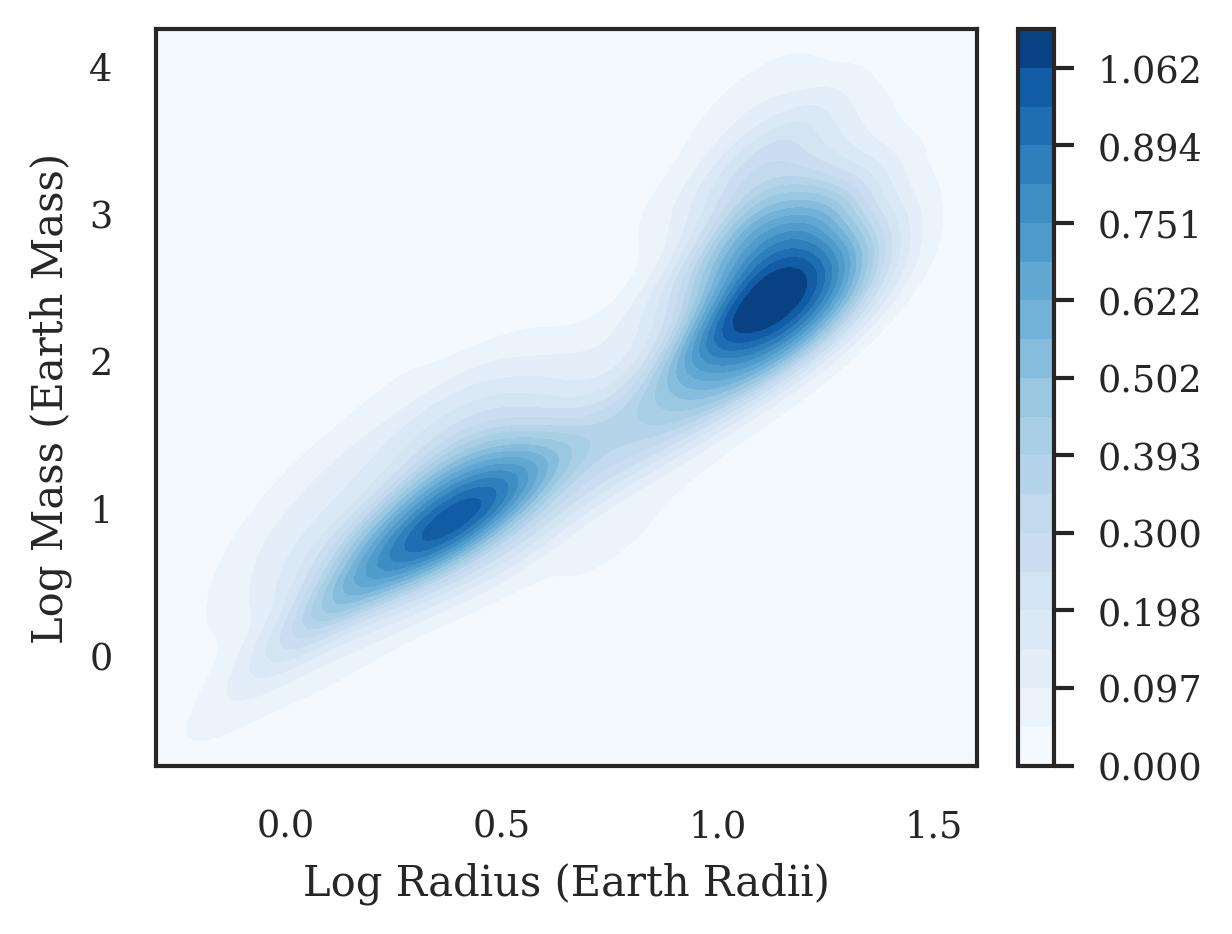

In [48]:
columns = ['radius', 'mass']

x = data['radius']
y = data['mass']

x = numpy.log10(x)
y = numpy.log10(y)
seaborn.kdeplot(pandas.DataFrame(numpy.log10(data[columns]), columns = columns), x = 'radius', y = 'mass', fill = True, cmap = 'Blues', levels = 20, thresh = 0, cbar = True)
# seaborn.scatterplot(numpy.log10(data[columns]), x = 'radius', y = 'mass', s = 5, color = 'black', zorder = 2)
# plot.gca().set_aspect('auto')

plot.xlim(-0.3, 1.6)
plot.ylim(-0.75, 4.25)

plot.xlabel('Log Radius (Earth Radii)')
plot.ylabel('Log Mass (Earth Mass)')

# if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()

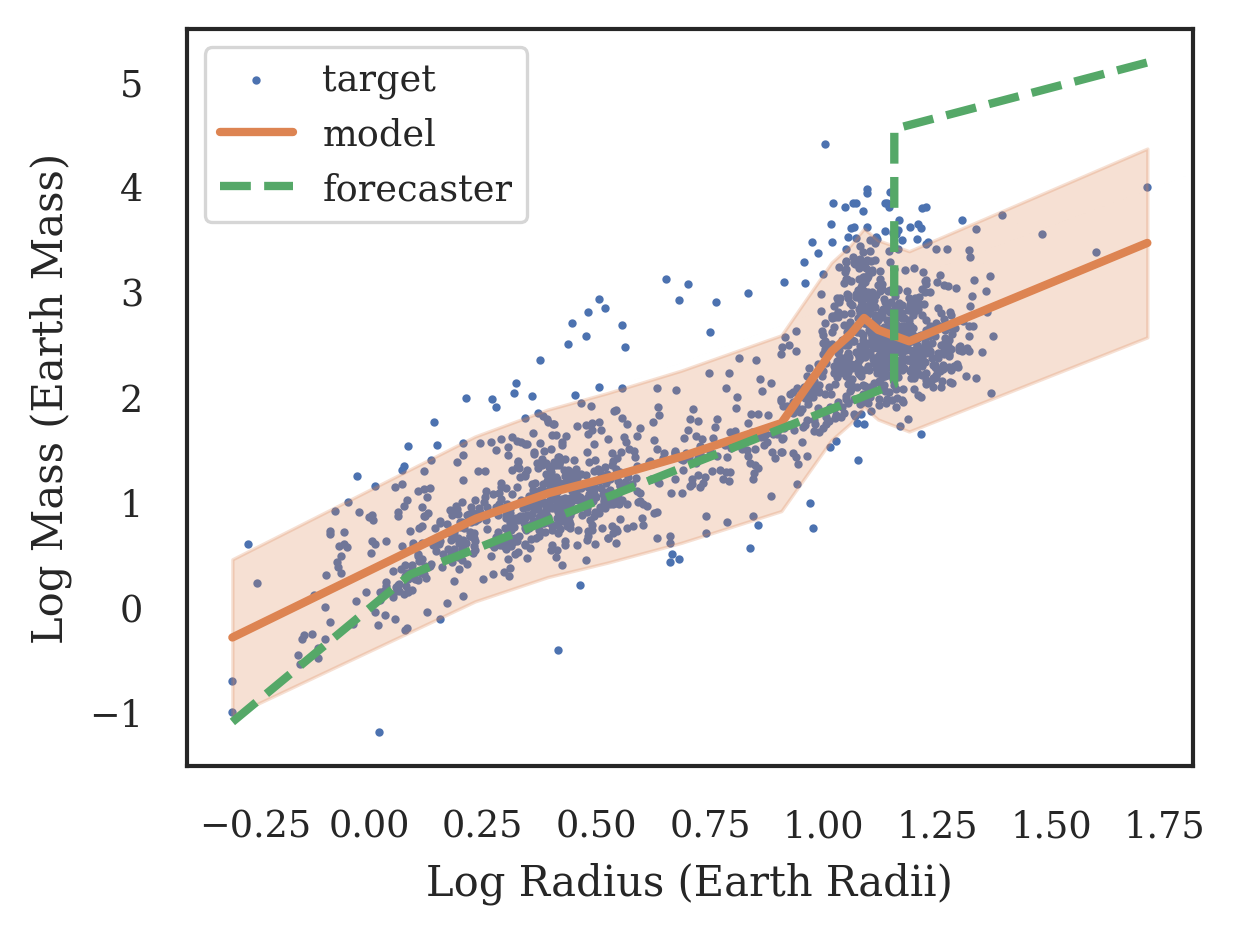

In [49]:
model = load_model()

xs = numpy.linspace(x.min(), x.max(), 10000)

ms = model(xs)
ms_e = model.error(xs)
ms2 = ForecasterRM.forecaster(xs)

plot.scatter(x, y)
plot.plot(xs, ms, color = 'C1')
plot.plot(xs, ms2, '--', color = 'C2')

plot.fill_between(xs, ms - ms_e, ms + ms_e, color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])

plot.xlabel('Log Radius (Earth Radii)')
plot.ylabel('Log Mass (Earth Mass)')

if save: plot.savefig(f'{path}/Figure 2.jpeg')

plot.show()

In [50]:
m = model(x)
m_e = model.error(x)
m_e2 = numpy.linspace(numpy.std(model.errors), numpy.std(model.errors), len(x))
out_error = len(x[(y < (m - m_e)) | (y > (m + m_e))])
out_error2 = len(x[(y < (m - m_e2)) | (y > (m + m_e2))])
out_error / len(x), out_error2 / len(x), len(x)

(0.06329113924050633, 0.44437041972018654, 1501)

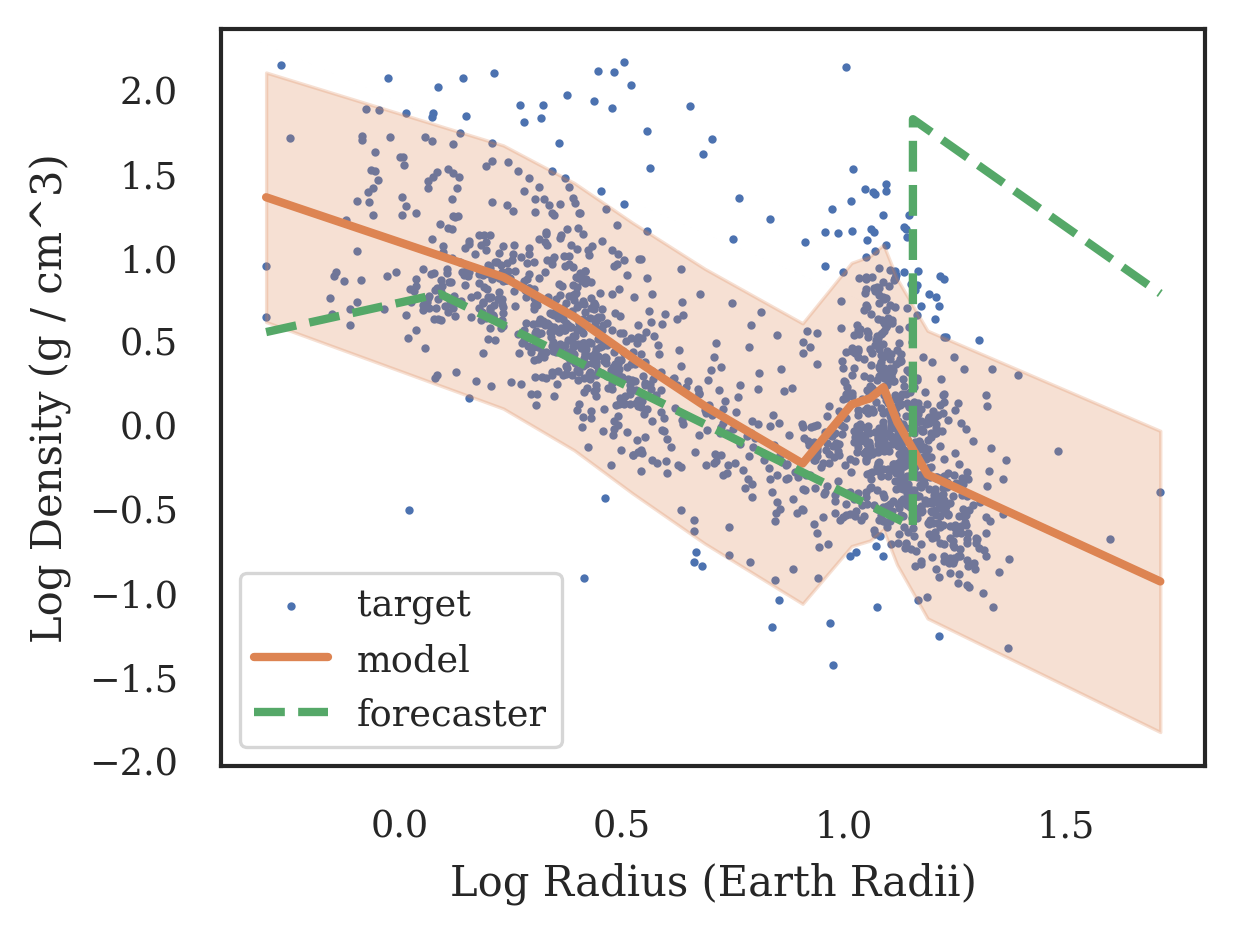

In [51]:
a = numpy.log10(5.51)  # Density of Earth in g / cm^3

plot.scatter(x, (y - 3 * x) + a)
ds = (ms - 3 * xs) + a
ds2 = (ms2 - 3 * xs) + a
plot.plot(xs, ds, color = 'C1')
plot.plot(xs, ds2, '--', color = 'C2')

plot.fill_between(xs,
                  ((ms - ms_e) - 3 * xs) + a,
                  ((ms + ms_e) - 3 * xs) + a,
                  color = 'C1', alpha = 0.25)

plot.legend(['target', 'model', 'forecaster'])
plot.xlabel('Log Radius (Earth Radii)')
plot.ylabel('Log Density (g / cm^3)')

if save: plot.savefig(f'{path}/Figure 4.jpeg')

plot.show()

In [52]:
ms1ts = []
ms2ts = []

for i in range(100):
    start_time = time.time()
    model(xs)
    ms1t = time.time() - start_time

    start_time = time.time()
    ForecasterRM.forecaster(xs)
    ms2t = time.time() - start_time

    ms1ts.append(ms1t)
    ms2ts.append(ms2t)

ms1t = numpy.mean(ms1ts) * 1e3
ms2t = numpy.mean(ms2ts) * 1e3

print('ExoRM time (ms): ', ms1t)
print('Forecaster time (ms): ', ms2t)

ExoRM time (ms):  0.10592937469482422
Forecaster time (ms):  0.09897947311401367


In [53]:
p_data = data.copy()
columns = ['radius', 'mass']
p_data[columns] = numpy.log10(p_data[columns])

p_data

,name,radius,mass,density
0,1RXS J160929.1-210524 b,1.270609,3.405346,0.392211
1,2MASS J02192210-3925225 b,1.207929,3.645210,1.050562
2,55 Cnc e,0.281033,0.907411,1.159608
3,AU Mic b,0.623598,1.757467,0.770323
4,AU Mic c,0.510545,1.133539,0.399856
...,...,...,...,...
1496,XO-7 b,1.186287,2.353451,0.062315
1497,ZTF J1230-2655 b,1.139471,3.846585,2.680225
1498,ZTF J1828+2308 b,1.046515,3.803223,4.609742
1499,bet Pic b,1.225309,3.803184,1.340467


In [54]:
p_data['ExoRM'] = model(p_data['radius'])
p_data['Forecaster'] = ForecasterRM.forecaster(p_data['radius'])

p_data['ExoRM res'] = (p_data['mass'] - p_data['ExoRM'])
p_data['Forecaster res'] = (p_data['mass'] - p_data['Forecaster'])

p_data['name_len'] = p_data['name'].str.len()
p_data = p_data.sort_values(
    by = ['name_len', 'name'],
).reset_index(drop = True)
p_data = p_data.drop(columns = ['name_len'])

columns = ['radius', 'mass', 'ExoRM', 'Forecaster', 'ExoRM res', 'Forecaster res']

p_data[columns] = p_data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (5 - 1) - int(math.floor(math.log10(abs(x)))))
)

p_data['winner'] = p_data.apply(
    lambda x: 'ExoRM' if abs(x['ExoRM res']) < abs(x['Forecaster res']) else 'Forecaster', axis = 1
)

if save: p_data[['name'] + columns + ['winner']].to_csv(f'{path}/ExoRM_results.csv', index = False)

p_data.head(10)

,name,radius,mass,density,ExoRM,Forecaster,ExoRM res,Forecaster res,winner
0,PH1 b,0.79099,2.22790,0.716014,1.58130,1.50000,0.64656,0.727910,ExoRM
1,PH2 b,1.00380,4.40530,24.766050,2.34910,1.86130,2.05620,2.544000,ExoRM
2,K2-3 b,0.35984,0.81954,0.549588,1.03190,0.76797,-0.21239,0.051572,Forecaster
3,K2-3 c,0.22789,0.51851,0.683681,0.82815,0.54395,-0.30964,-0.025436,Forecaster
4,K2-3 d,0.18184,0.87506,2.135652,0.73098,0.46578,0.14408,0.409280,ExoRM
5,XO-1 b,1.12290,2.45640,0.122372,2.63110,2.06350,-0.17469,0.392910,ExoRM
6,XO-3 b,1.13480,3.57370,1.476223,2.61210,2.08380,0.96156,1.489900,ExoRM
7,XO-4 b,1.17350,2.75260,0.170671,2.55060,4.56690,0.20198,-1.814400,ExoRM
8,XO-5 b,1.10650,2.57770,0.181188,2.68490,2.03570,-0.10722,0.542020,ExoRM
9,XO-6 b,1.36550,3.14560,0.111953,2.84380,4.78490,0.30186,-1.639300,ExoRM


In [55]:
p_data['ExoRM res'].abs().describe(), p_data['Forecaster res'].abs().describe()

(count    1501.000000
 mean        0.329297
 std         0.287704
 min         0.000102
 25%         0.127080
 50%         0.258730
 75%         0.446220
 max         2.056200
 Name: ExoRM res, dtype: float64,
 count    1501.000000
 mean        0.724194
 std         0.727666
 min         0.000089
 25%         0.164140
 50%         0.413470
 75%         1.050500
 max         2.969000
 Name: Forecaster res, dtype: float64)

In [56]:
p_data['winner'].value_counts() / len(p_data)

winner
ExoRM         0.677548
Forecaster    0.322452
Name: count, dtype: float64

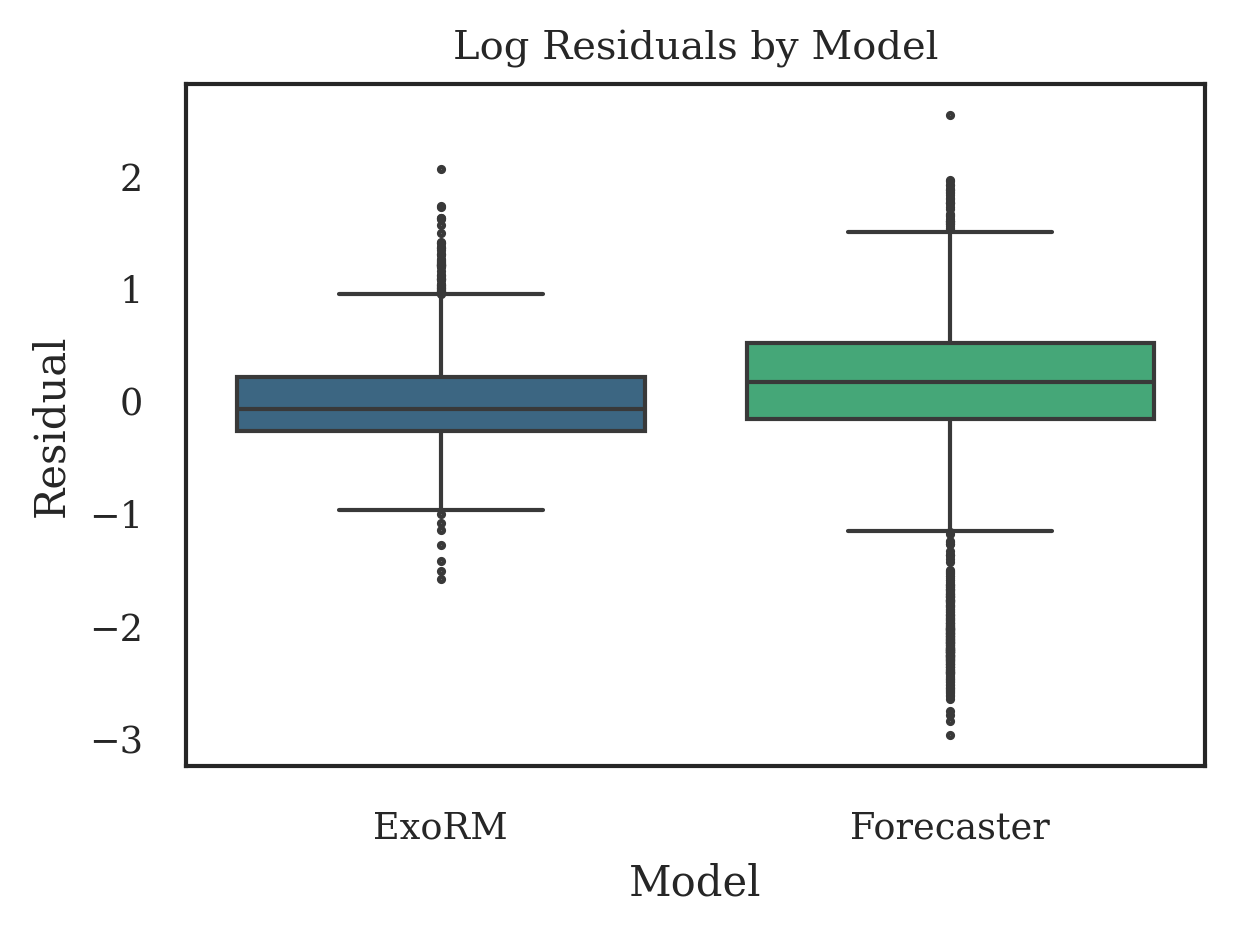

,Model,Residual
0,ExoRM,0.64656
1,ExoRM,2.05620
2,ExoRM,-0.21239
3,ExoRM,-0.30964
4,ExoRM,0.14408
...,...,...
2997,Forecaster,0.15377
2998,Forecaster,-1.27180
2999,Forecaster,-0.96084
3000,Forecaster,-0.97426


In [57]:
p_data_long = pandas.melt(
    p_data,
    value_vars = ['ExoRM res', 'Forecaster res'],
    var_name = 'Model',
    value_name = 'Residual'
)

p_data_long['Model'] = p_data_long['Model'].map(lambda x: 'ExoRM' if x == 'ExoRM res' else 'Forecaster')
seaborn.boxplot(data = p_data_long, x = 'Model', y = 'Residual', hue = 'Model', palette = 'viridis', zorder = 1)

plot.title('Log Residuals by Model')

if save: plot.savefig(f'{path}/Figure 3.jpeg')

plot.show()

p_data_long

In [58]:
10 ** xs[numpy.argmin(numpy.abs((10 ** ms) - 317.9 * 13))]
# the deuterium burning limit radius

np.float64(51.56139999999999)

In [59]:
numpy.mean(numpy.abs(ms - ms2))
# average change metween two models

np.float64(0.7569513981657238)

In [60]:
10 ** xs[numpy.argmin(ds)], 10 ** xs[numpy.argmax(ds)], 10 ** xs[numpy.argmin(ds2)], 10 ** xs[numpy.argmax(ds2)]
# min and max density points for both models

(np.float64(51.56139999999999),
 np.float64(0.5),
 np.float64(14.294657075506185),
 np.float64(14.3012861642863))

In [61]:
10 ** min(ds), 10 ** max(ds), 10 ** min(ds2), 10 ** max(ds2)
# min and max density values for both models

(np.float64(0.11668493251546715),
 np.float64(22.70620580732498),
 np.float64(0.24769768987347615),
 np.float64(66.2861139411983))

In [62]:
10 ** model.x_min, 10 ** model.x_max

TypeError: unsupported operand type(s) for ** or pow(): 'int' and 'NoneType'

In [ ]:
exoplanet_data = read_exoplanet_data()

exoplanet_data[['name', 'radius', 'mass', 'year']] = exoplanet_data[['pl_name', 'pl_rade', 'pl_bmasse', 'disc_year']]
exoplanet_data = exoplanet_data[exoplanet_data['pl_controv_flag'] == 0]
exoplanet_data = exoplanet_data.drop(columns = ['pl_controv_flag', 'pl_name', 'pl_rade', 'pl_bmasse', 'disc_year'])
exoplanet_data = exoplanet_data[exoplanet_data['radius'].notna() & exoplanet_data['mass'].notna()]
exoplanet_data[['radius', 'mass']] = numpy.log10(exoplanet_data[['radius', 'mass']])

old_exoplanet_data = exoplanet_data[exoplanet_data['year'] <= 2017].copy()
new_exoplanet_data = exoplanet_data[exoplanet_data['year'] > 2017].copy()
new_exoplanet_data, old_exoplanet_data

(                   name    radius      mass  year
 253            K2-280 b  0.875061  1.569374  2018
 276           HATS-36 b  1.141234  3.009511  2018
 290            K2-222 b  0.371068  0.939519  2018
 307            K2-216 b  0.243038  0.903090  2018
 334            K2-295 b  1.002359  2.027240  2018
 ...                 ...       ...       ...   ...
 37318          K2-146 b  0.311754  0.761176  2018
 37327  EPIC 211945201 b  0.786751  1.431364  2018
 37623          K2-199 b  0.238046  0.838849  2018
 37630          K2-199 c  0.454845  1.093422  2018
 37739      Kepler-595 c  0.003891  0.518514  2020
 
 [979 rows x 4 columns],
               name    radius      mass  year
 2       Kepler-6 b  1.164844  2.326971  2009
 6       Kepler-6 b  1.171141  2.327602  2009
 11      Kepler-6 b  1.117381  2.303599  2009
 15      Kepler-6 b  1.117381  2.313099  2009
 58     Kepler-32 c  0.305351  0.886491  2011
 ...            ...       ...       ...   ...
 38362  Kepler-55 b  0.411620  1.633468

In [ ]:
new_exoplanet_data = new_exoplanet_data.sort_values(by = ['name', 'year'], ascending = [True, False]).drop_duplicates(subset = 'name').reset_index(drop = True)
old_exoplanet_data = old_exoplanet_data.sort_values(by = ['name', 'year'], ascending = [True, False]).drop_duplicates(subset = 'name').reset_index(drop = True)
new_exoplanet_data, old_exoplanet_data

(                           name    radius      mass  year
 0     2MASS J02192210-3925225 b  1.207929  3.645210  2015
 1                      AU Mic b  0.623598  1.757467  2020
 2                      AU Mic c  0.510545  1.133539  2021
 3                   BD+20 594 b  0.411295  1.347293  2016
 4                  BD+60 1417 b  1.166837  3.678284  2021
 ...                         ...       ...       ...   ...
 1382                     XO-6 b  1.365537  3.145648  2016
 1383                     XO-7 b  1.186287  2.353451  2019
 1384           ZTF J1230-2655 b  1.139471  3.846585  2025
 1385           ZTF J1828+2308 b  1.046515  3.803223  2025
 1386                   pi Men c  0.324282  0.633468  2018
 
 [1387 rows x 4 columns],
                         name    radius      mass  year
 0    1RXS J160929.1-210524 b  1.270609  3.405346  2008
 1                   55 Cnc e  0.281033  0.907411  2004
 2                   CT Cha b  1.391993  3.732635  2007
 3                  CoRoT-1 b  1.222716 

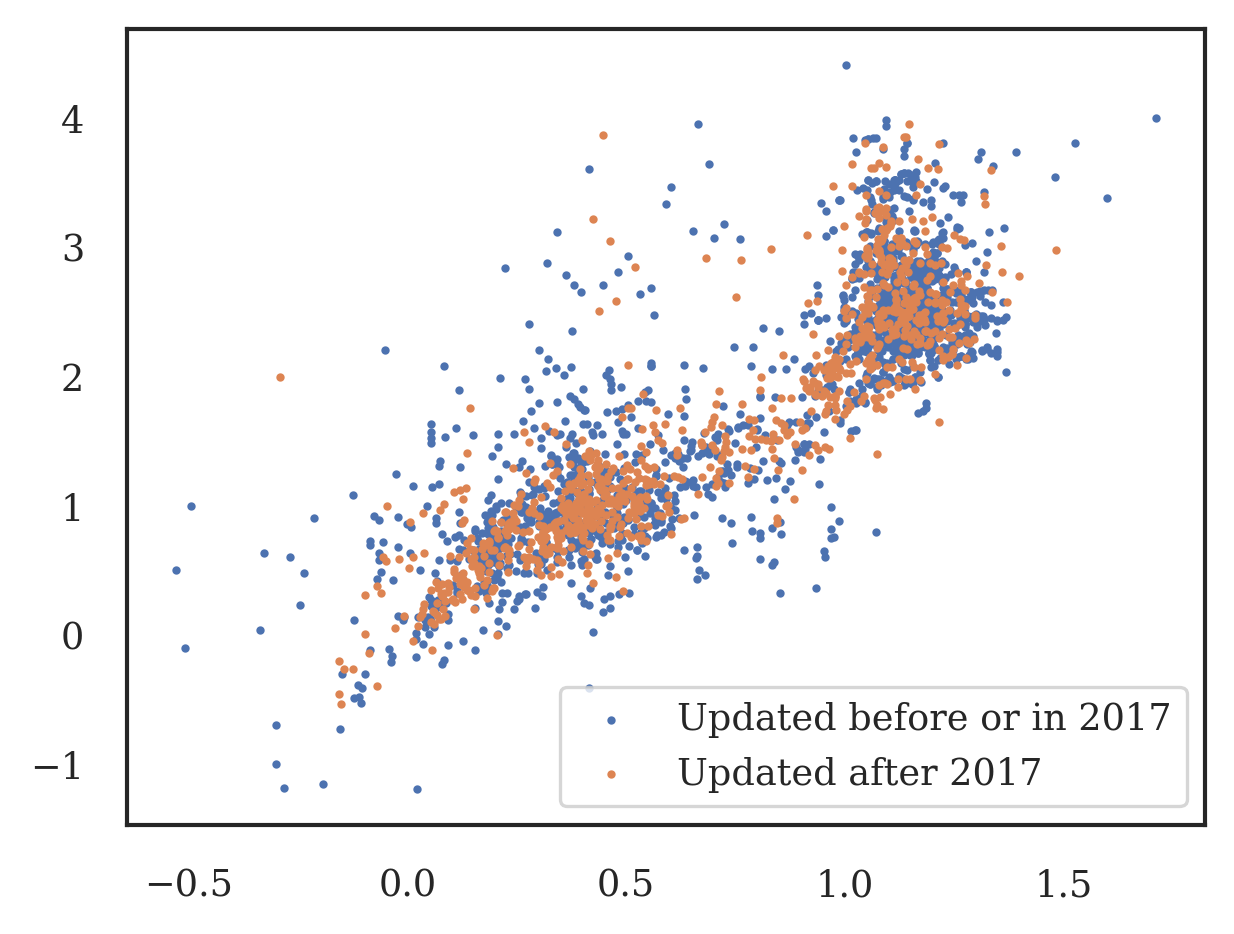

In [ ]:
plot.scatter(old_exoplanet_data['radius'], old_exoplanet_data['mass'])
plot.scatter(new_exoplanet_data['radius'], new_exoplanet_data['mass'])

plot.legend(['Updated before or in 2017', 'Updated after 2017'])

if save: plot.savefig(f'{path}/Figure 1.jpeg')